### 一元线性回归

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def true_fun(X):
    return 2.0 * X + 0.7

np.random.seed(0)
n_samples = 30

x_train = np.sort(np.random.rand(n_samples))
noise = (np.random.rand(n_samples) - 0.5) * 0.1   # 范围 [-0.05, 0.05)
y_train = (true_fun(x_train) + noise).reshape(n_samples, 1)


In [67]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

for i, (x, y) in enumerate(zip(x_train, y_train)):
    if i > 5:
        break
    print(x, y)

x_train shape: (30,)
y_train shape: (30, 1)
0.02021839744032572 [0.71689236]
0.07103605819788694 [0.86949549]
0.08712929970154071 [0.86987363]
0.11827442586893322 [0.94339225]
0.1433532874090464 [0.93858555]
0.3834415188257777 [1.47864659]


实际模型会存在一个偏置量$b$，

以一元为例，$y=w_1x_1+b=w^Tb=w_1x_1+w_0x_0$

实际使用梯度下降法时可以添加一维并令$x_0=1$,则求出的$w_0=b$

In [68]:
# 添加偏置, 将权重和偏置合并在一个向量中
w = np.ones((2, 1))
print("初始偏置: b = ", w[0, 0])
print("初始权重: w = ", w[1, 0])

# 同时需要对x_train中添加一项常数项，对应的乘上偏置
# 添加一维数据
data_X = [] 
for x in x_train:
    data_X.append([1,x])
data_X = np.array((data_X))

print("data_X shape:", data_X.shape)



初始偏置: b =  1.0
初始权重: w =  1.0
data_X shape: (30, 2)


设$x$是(m,n)维的矩阵，$y$是(m,1)维度的矩阵，$h_{\theta}$是预测的值，维度与$y$相同，那么梯度用矩阵表示如下:
$$
\frac{\partial J(\theta)}{\partial \theta_{j}} = \frac{1}{m}x^{T}(h_{\theta}-y)
$$

In [69]:
# 迭代，梯度下降
N_iter = 1000
alpha = 0.1

for i in range(N_iter):
    # 计算预测值
    y_pred = np.dot(data_X, w)
    # 计算误差
    error = y_pred - y_train
    # 计算梯度
    grad = data_X.transpose().dot(error) / n_samples
    # 更新权重
    w = w - alpha * grad

print("最终权重: w = ", w[1, 0])
print("最终偏置: b = ", w[0, 0])


最终权重: w =  1.9821952767846185
最终偏置: b =  0.7056089744383214


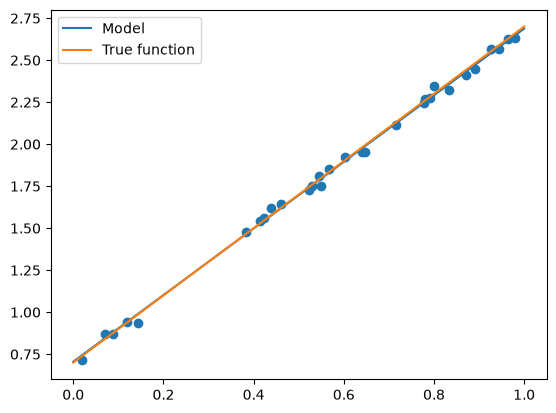

In [71]:
X_test = np.linspace(0, 1, 100)
plt.plot(X_test, X_test*w[1][0]+w[0][0], label="Model") 
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(x_train,y_train) # 画出训练集的点
plt.legend(loc="best")
plt.show()

输出参数w: [[1.98476735]]
输出参数b: [0.70402262]


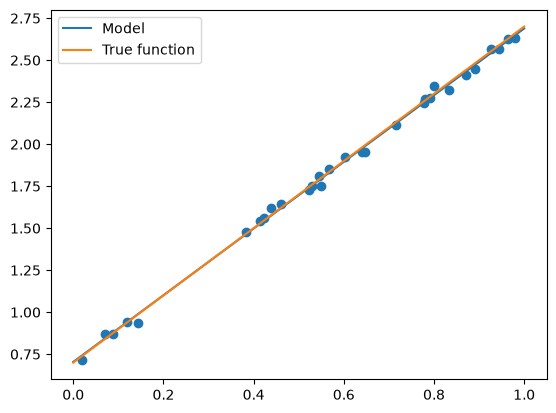

In [73]:
# scikit-learn
from sklearn.linear_model import LinearRegression

model = LinearRegression(n_jobs=-1)
model.fit(x_train[:, np.newaxis], y_train)
print("输出参数w:",model.coef_) # 输出参数w1
print("输出参数b:",model.intercept_) # 输出参数b

X_test = np.linspace(0, 1, 100)
plt.plot(X_test, model.predict(X_test[:, np.newaxis]), label="Model")
plt.plot(X_test, true_fun(X_test), label="True function")
plt.scatter(x_train,y_train) # 画出训练集的点
plt.legend(loc="best")
plt.show()
